In [10]:
%matplotlib inline
import math
import random
import warnings

import numpy as np
import torch
import torch.nn.functional as F
from torch import nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## 2 卷积和池化层

### 2.1 理论计算题
<img src="./hw03_pic/2-1.png" width="600">

### 2.2 编程题

In [11]:
import torch
import torch.nn.functional as F

def pad2d_for_pooling(X, padding):
    if isinstance(padding, int):
        pad_h = pad_w = padding
    else:
        pad_h, pad_w = padding

    C, H, W = X.shape
    Y = torch.full(
        (C, H + 2 * pad_h, W + 2 * pad_w),
        float('-inf'),
        dtype=X.dtype,
        device=X.device
    )
    Y[:, pad_h:pad_h + H, pad_w:pad_w + W] = X
    return Y

def max_pool2d_forward(X, pool_size=2, stride=None, padding=0):
    if isinstance(pool_size, int):
        pH = pW = pool_size
    else:
        pH, pW = pool_size

    if stride is None:
        stride = pool_size

    if isinstance(stride, int):
        sH = sW = stride
    else:
        sH, sW = stride

    X_pad = pad2d_for_pooling(X, padding)

    C, H, W = X_pad.shape
    out_h = (H - pH) // sH + 1
    out_w = (W - pW) // sW + 1

    Y = torch.zeros((C, out_h, out_w), dtype=X.dtype, device=X.device)

    for c in range(C):
        for i in range(out_h):
            for j in range(out_w):
                h_start = i * sH
                w_start = j * sW
                region = X_pad[c, h_start:h_start + pH, w_start:w_start + pW]
                Y[c, i, j] = region.max()

    return Y

# 测试
X = torch.arange(3 * 6 * 6, dtype=torch.float32).reshape(3, 6, 6)

pool_manual = max_pool2d_forward(X, pool_size=2, stride=2, padding=0)
pool_ref = F.max_pool2d(X.unsqueeze(0), kernel_size=2, stride=2, padding=0).squeeze(0)

print('MaxPool 输出形状:', tuple(pool_manual.shape))
print('手动实现结果:')
print(pool_manual)
print('与 PyTorch 是否一致:', torch.allclose(pool_manual, pool_ref))

MaxPool 输出形状: (3, 3, 3)
手动实现结果:
tensor([[[  7.,   9.,  11.],
         [ 19.,  21.,  23.],
         [ 31.,  33.,  35.]],

        [[ 43.,  45.,  47.],
         [ 55.,  57.,  59.],
         [ 67.,  69.,  71.]],

        [[ 79.,  81.,  83.],
         [ 91.,  93.,  95.],
         [103., 105., 107.]]])
与 PyTorch 是否一致: True


## 3 LeNet、AlexNet、VGG 和 NiN

### 3.1 理论计算题
<img src="./hw03_pic/3-1.png" width="300">

### 3.2 编程题 

In [12]:
def nin_block(in_channels, out_channels, kernel_size, stride, padding):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU(),
    )

X = torch.randn(1, 3, 32, 32)
blk = nin_block(3, 16, kernel_size=5, stride=1, padding=2)
Y = blk(X)
print(blk)
print('输入形状:', tuple(X.shape))
print('输出形状:', tuple(Y.shape))

Sequential(
  (0): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (1): ReLU()
  (2): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
  (3): ReLU()
  (4): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
  (5): ReLU()
)
输入形状: (1, 3, 32, 32)
输出形状: (1, 16, 32, 32)


## 4 Inception, 批量归一化和残差网络

### 4.1 理论计算题
<img src="./hw03_pic/4-1.png" width="600">

### 4.2 编程题

In [13]:
class Residual(nn.Module):
    def __init__(self, in_channels, out_channels, use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=strides)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = None
        if use_1x1conv:
            self.conv3 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=strides)

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3 is not None:
            X = self.conv3(X)
        Y += X
        return F.relu(Y)

X = torch.randn(4, 3, 32, 32)
blk_same = Residual(3, 3, use_1x1conv=False, strides=1)
blk_down = Residual(3, 8, use_1x1conv=True, strides=2)

print('不改变形状时的输出:', tuple(blk_same(X).shape))
print('使用 1x1 卷积后的输出:', tuple(blk_down(X).shape))

不改变形状时的输出: (4, 3, 32, 32)
使用 1x1 卷积后的输出: (4, 8, 16, 16)


## 5 图像增广，微调和样式迁移

### 5.1 理论计算题

1. **为什么底层特征提取层使用较小学习率或冻结，而顶层输出层使用较大学习率？**  
在预训练模型中，底层特征提取层通常已经在大型数据集上学习到了比较通用的图像特征。这些特征对很多视觉任务都有用，因此不需要大幅度修改。如果对这些层使用过大的学习率，可能会破坏已经学到的有效特征，导致模型性能下降。

    顶层输出层通常是针对源数据集类别设计的。当迁移到新的目标数据集时，类别数量和类别含义通常发生了变化，所以顶层输出层需要重新初始化并重新学习。设置较大的学习率，使它能够更快适应新任务。

2. **如果目标数据集非常小，且与源数据集非常相似，应该采取什么微调策略？**  
可以固定底层和中间层的参数，只替换最后的分类层，并只训练新的分类层。这样可以充分利用预训练模型已经学到的通用特征，同时减少需要训练的参数数量，降低过拟合风险。如果效果不够好，也可以只解冻靠近输出端的少数几层，并使用较小学习率进行微调。训练过程中还可以配合数据增广、权重衰减、Dropout、早停等方法进一步防止过拟合。

### 5.2 编程题 

Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=[0.5, 1.5], contrast=[0.5, 1.5], saturation=[0.5, 1.5], hue=None)
    ToTensor()
)
增强后 Tensor 形状: (3, 224, 224)


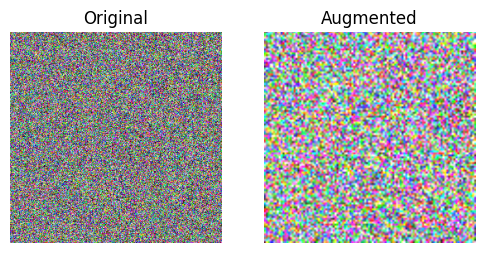

In [14]:
train_augs = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.08, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    transforms.ToTensor(),
])

print(train_augs)

# 用随机图像演示增强后结果
img = Image.fromarray(np.uint8(np.random.rand(256, 256, 3) * 255))
aug_img = train_augs(img)
print('增强后 Tensor 形状:', tuple(aug_img.shape))

plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(aug_img.permute(1, 2, 0).clamp(0, 1))
plt.title('Augmented')
plt.axis('off')
plt.show()

## 6 目标检测，计算机视觉训练技巧

### 6.1 理论计算题
<img src="./hw03_pic/6-1.png" width="600">


### 6.2 编程题 

In [15]:
import torch
import torch.nn.functional as F

def label_smoothing(labels, num_classes, epsilon=0.1, device=None):
    labels = labels.long()
    smooth = torch.full(
        (labels.shape[0], num_classes),
        epsilon / (num_classes - 1),
        device=device
    )
    smooth.scatter_(1, labels.unsqueeze(1), 1 - epsilon)
    return smooth

def label_smoothing_cross_entropy(logits, labels, epsilon=0.1):
    num_classes = logits.shape[1]

    smooth_labels = label_smoothing(
        labels,
        num_classes,
        epsilon,
        device=logits.device
    )

    log_probs = F.log_softmax(logits, dim=1)
    loss = -(smooth_labels * log_probs).sum(dim=1).mean()

    return loss, smooth_labels

# 测试
logits = torch.tensor([
    [2.0, 0.5, 0.1, -1.0],
    [0.2, 0.3, 2.5, 0.1],
    [0.1, 2.0, 0.3, 0.4]
])

labels = torch.tensor([0, 2, 1])

loss, smoothed = label_smoothing_cross_entropy(logits, labels, epsilon=0.1)

print('原始标签:', labels.tolist())
print('平滑后分布:\n', smoothed)
print('每行概率和:', smoothed.sum(dim=1))
print('标签平滑交叉熵损失:', loss.item())

原始标签: [0, 2, 1]
平滑后分布:
 tensor([[0.9000, 0.0333, 0.0333, 0.0333],
        [0.0333, 0.0333, 0.9000, 0.0333],
        [0.0333, 0.9000, 0.0333, 0.0333]])
每行概率和: tensor([1., 1., 1.])
标签平滑交叉熵损失: 0.5535935759544373
